In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "src"))

from synthetic_data_generation.markov_process_generation import (
    GaussianEmissionGenerator,
)
generator = GaussianEmissionGenerator(
    emission_params=np.array([
        [0.0, 1.0],
        [5.0, 2.0],
    ]),
    states=np.array([0, 1]),
    initial_probs=np.array([0.5, 0.5]),
    trans_matrix=np.array([
        [0.9, 0.1],
        [0.2, 0.8],
    ]),
    data_count=100000,
)

rows = generator.generate_data()
output_dir = project_root / "data" / "synthetic"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "samples.csv"
generator.write_csv(output_path, rows)

### State-conditional data distribution vs empirical distribution

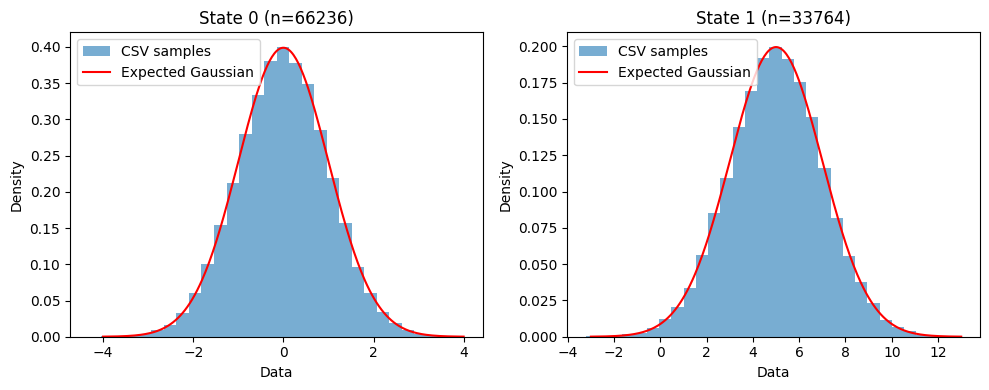

In [ ]:
df = pd.read_csv(project_root / "data" / "synthetic" / "samples.csv")
states = sorted(df["state"].unique())

fig, axes = plt.subplots(
    1, len(states),
    figsize=(5 * len(states), 4),
    squeeze=False,
)

for ax, state in zip(axes[0], states):
    values = df.loc[df["state"] == state, "data"]

    ax.hist(
        values, bins=30, density=True,
        alpha=0.6, label="CSV samples",
    )

    # Use the parameters that generated this CSV.
    mean, std = generator.emission_params[int(state)]
    x = np.linspace(mean - 4 * std, mean + 4 * std, 300)
    density = (
        np.exp(-0.5 * ((x - mean) / std) ** 2)
        / (std * np.sqrt(2 * np.pi))
    )
    ax.plot(x, density, color="red", label="Expected Gaussian")

    ax.set_title(f"State {state} (n={len(values)})")
    ax.set_xlabel("Data")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()